#**Down Sampling and Up Sampling**

**Course:** Pengolahan Citra Digital  
**Task:** Analyze the effects of Down Sampling (Max, Average, Median) and Up Sampling (Nearest Neighbor, Bilinear, Bicubic).

**Name:** Renata Ayu Sekar Kumala (25/557585/PA/23428)


This notebook uses three images with different characteristics:
1. Smooth gradient: low frequency/smooth intensity changes.
2. High frequency checkerboard: repetitive fine texture.
3. Edge rich shapes: strong object boundaries and sharp transitions.

All experiments use a scale factor of 2 for clear comparison.

Smooth Gradient: (256, 256), dtype=uint8, min=63, max=242
High-Frequency Checkerboard: (256, 256), dtype=uint8, min=0, max=255
Edge-Rich Shapes: (256, 256), dtype=uint8, min=30, max=245


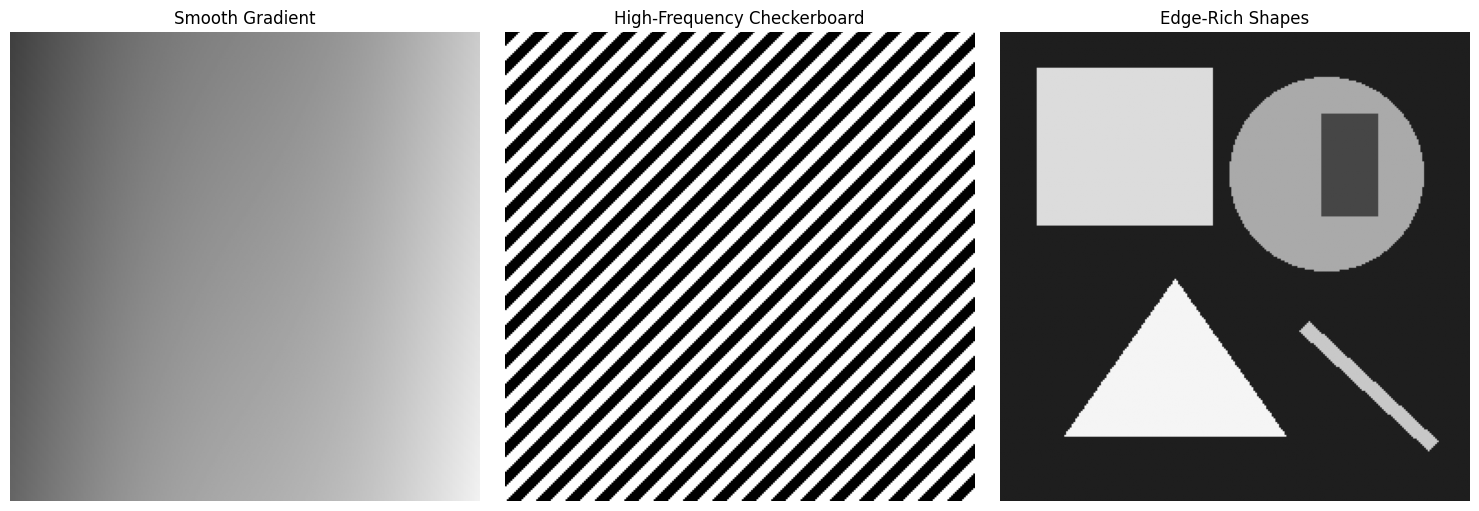

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path

plt.rcParams["figure.figsize"] = (14, 8)

IMAGE_DIR = Path("/content/images")
image_files = {
    "Smooth Gradient": IMAGE_DIR / "smooth_gradient.png",
    "High-Frequency Checkerboard": IMAGE_DIR / "high_frequency_checkerboard.png",
    "Edge-Rich Shapes": IMAGE_DIR / "edge_rich_shapes.png",
}

def load_gray(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    return img

images = {name: load_gray(path) for name, path in image_files.items()}

for name, img in images.items():
    print(f"{name}: {img.shape}, dtype={img.dtype}, min={img.min()}, max={img.max()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()


# 1. Down Sampling

Down sampling reduces spatial resolution. Here, every non overlapping **2×2 block** is replaced by one pixel.

- **Max:** chooses the largest intensity in each block.
- **Average:** uses the mean intensity in each block.
- **Median:** uses the median intensity in each block.

These methods can produce noticeably different results, especially around edges and high frequency textures.

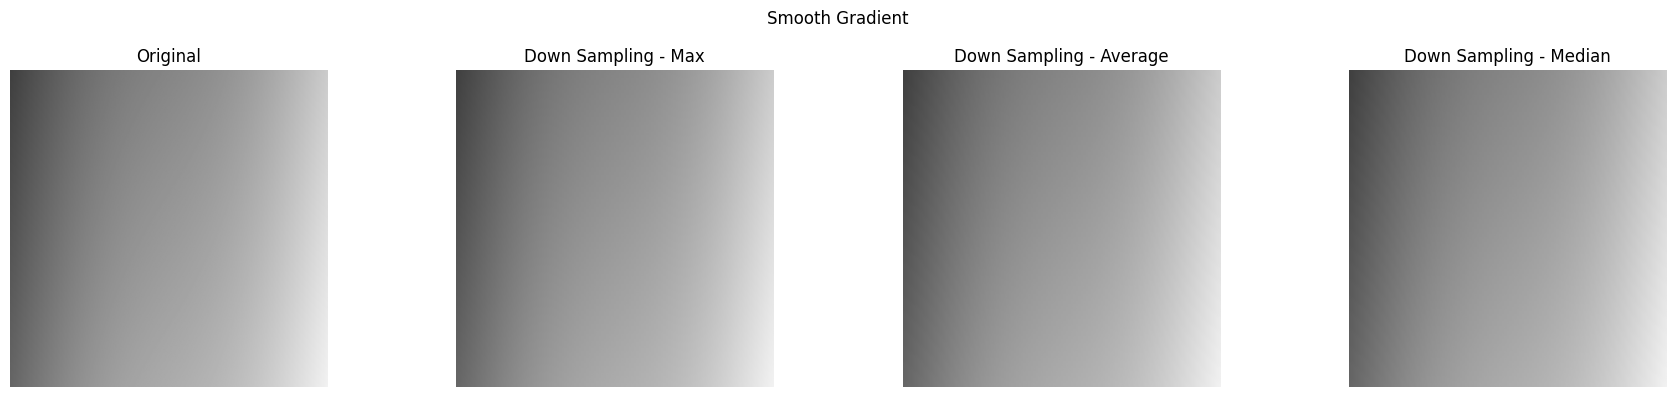

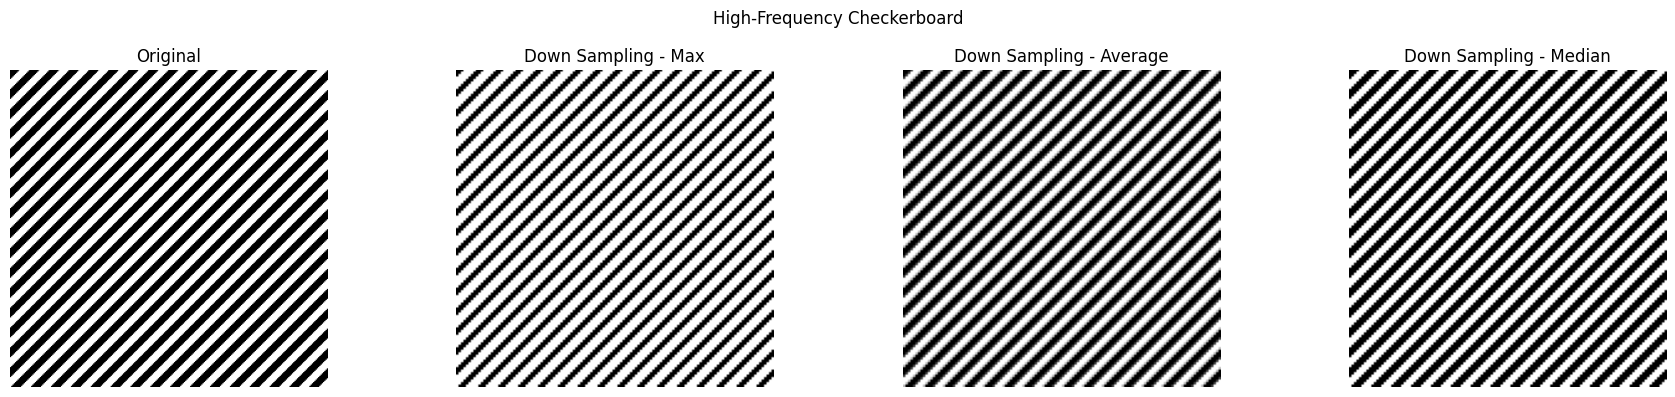

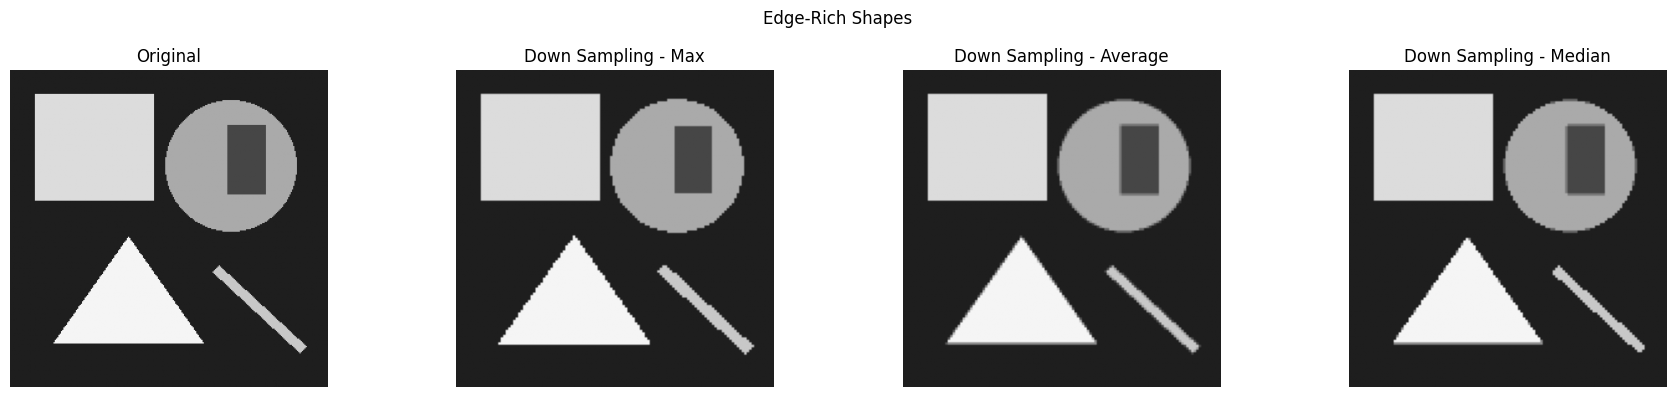

In [3]:
def downsample_pool(img, factor=2, method="average"):
    h, w = img.shape
    h2, w2 = h // factor, w // factor
    cropped = img[:h2*factor, :w2*factor]
    blocks = cropped.reshape(h2, factor, w2, factor)

    if method == "max":
        out = blocks.max(axis=(1, 3))
    elif method == "average":
        out = blocks.mean(axis=(1, 3))
    elif method == "median":
        out = np.median(blocks, axis=(1, 3))
    else:
        raise ValueError("method must be max, average, or median")

    return np.rint(out).astype(np.uint8)

down_methods = ["max", "average", "median"]

for name, img in images.items():
    results = {m: downsample_pool(img, 2, m) for m in down_methods}
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("Original")
    axes[0].axis("off")
    for ax, m in zip(axes[1:], down_methods):
        ax.imshow(results[m], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"Down Sampling - {m.title()}")
        ax.axis("off")
    fig.suptitle(name)
    plt.tight_layout()
    plt.show()


# Down Sampling Analysis

**Max pooling** preserves bright/high intensity structures and can make bright edges or objects appear wider or stronger. It is sensitive to isolated bright pixels.

**Average pooling** produces smoother results because each output pixel represents the average of a 2×2 neighborhood. It generally reduces noise and high frequency variation, but sharp edges become softer.

**Median pooling** is more robust to isolated impulse noise and tends to preserve boundaries better than averaging. On highly regular textures such as a checkerboard, however, median pooling can strongly change the pattern depending on the alignment of the sampling blocks.


In [5]:
#Quantitative comparison: mean intensity and standard deviation
print("Down-sampling statistics (factor = 2)")
for name, img in images.items():
    print(f"\n{name}")
    print(f"Original : mean={img.mean():.2f}, std={img.std():.2f}")
    for m in down_methods:
        out = downsample_pool(img, 2, m)
        print(f"{m.title():8s}: mean={out.mean():.2f}, std={out.std():.2f}")

Down-sampling statistics (factor = 2)

Smooth Gradient
Original : mean=152.50, std=35.90
Max     : mean=152.85, std=35.90
Average : mean=152.50, std=35.90
Median  : mean=152.50, std=35.90

High-Frequency Checkerboard
Original : mean=127.50, std=127.50
Max     : mean=159.38, std=123.45
Average : mean=127.50, std=114.89
Median  : mean=127.50, std=127.50

Edge-Rich Shapes
Original : mean=89.22, std=84.99
Max     : mean=91.19, std=85.71
Average : mean=89.22, std=84.12
Median  : mean=89.22, std=84.56


# 2. Up Sampling

Up sampling increases spatial resolution. The output size is doubled in both dimensions.

- **Nearest Neighbor (NN):** copies the value of the nearest input pixel.
- **Bilinear:** estimates a pixel from a weighted combination of neighboring pixels.
- **Bicubic:** uses a larger neighborhood and a cubic interpolation model, usually giving smoother and more visually natural results.


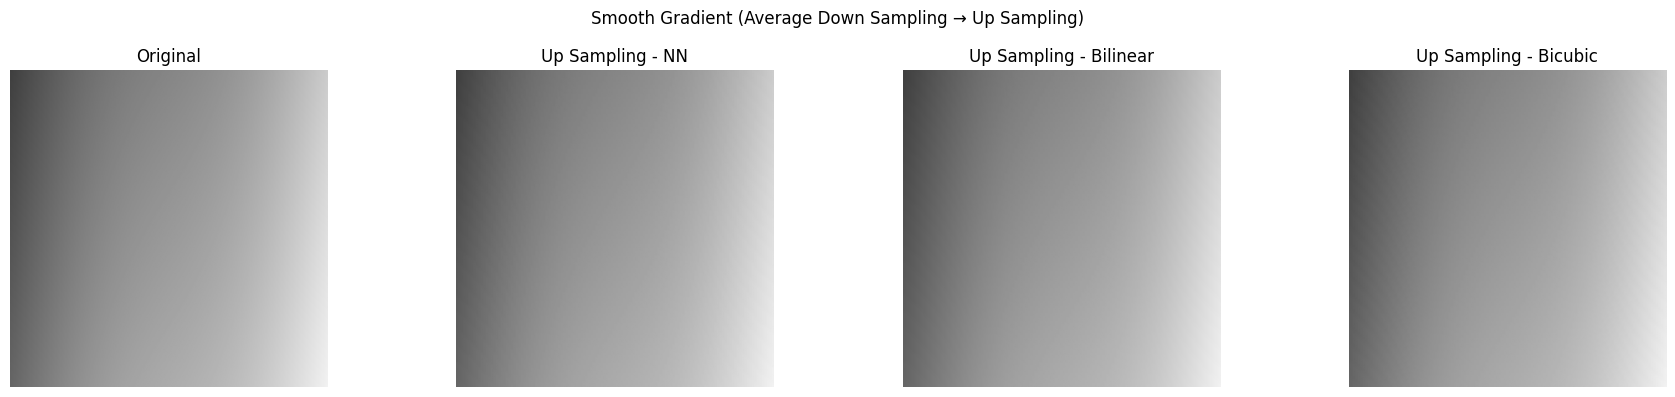

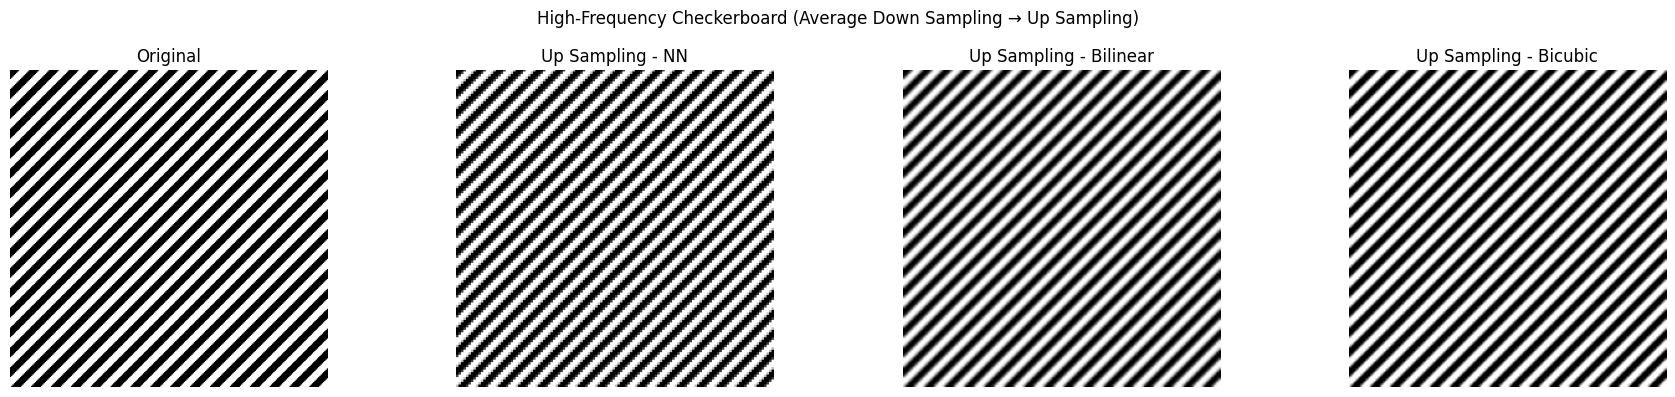

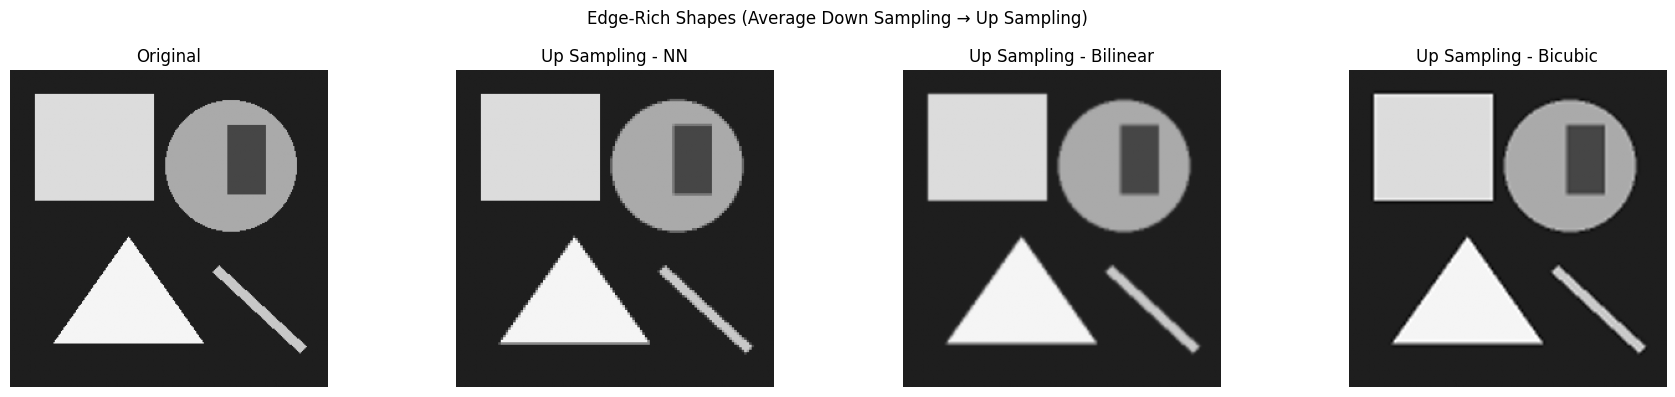

In [9]:
def upsample(img, factor=2, method="nn"):
    h, w = img.shape
    interpolation = {
        "nn": cv2.INTER_NEAREST,
        "bilinear": cv2.INTER_LINEAR,
        "bicubic": cv2.INTER_CUBIC
    }[method]
    return cv2.resize(img, (w*factor, h*factor), interpolation=interpolation)

up_methods = ["nn", "bilinear", "bicubic"]

for name, img in images.items():
    down = downsample_pool(img, 2, "average")
    results = {m: upsample(down, 2, m) for m in up_methods}

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("Original")
    axes[0].axis("off")
    for ax, m in zip(axes[1:], up_methods):
        ax.imshow(results[m], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"Up Sampling - {m.upper() if m=='nn' else m.title()}")
        ax.axis("off")
    fig.suptitle(name + " (Average Down Sampling → Up Sampling)")
    plt.tight_layout()
    plt.show()


# Up Sampling Analysis

**Nearest Neighbor** is the simplest and fastest method. It preserves exact input pixel values but creates visible blockiness and jagged boundaries.

**Bilinear interpolation** produces smoother transitions because each new pixel is estimated from nearby pixels. It reduces blockiness but can blur edges.

**Bicubic interpolation** generally provides smoother and more visually pleasing results than nearest neighbor and often retains edges better than bilinear. However, it can introduce slight ringing/overshoot near very sharp transitions.

Important: up sampling does **not** recreate information that was lost during down sampling. It only estimates new pixel values from the available samples.


In [10]:
#Compare interpolation error after Average Down -> Up
#MSE is measured against the original image. Lower is better for this numerical metric.
def mse(a, b):
    return np.mean((a.astype(np.float32) - b.astype(np.float32))**2)

print("MSE after Average Down Sampling -> Up Sampling (factor = 2)")
for name, img in images.items():
    down = downsample_pool(img, 2, "average")
    print(f"\n{name}")
    for m in up_methods:
        restored = upsample(down, 2, m)
        print(f"{m.upper() if m=='nn' else m.title():10s}: MSE = {mse(img, restored):.2f}")


MSE after Average Down Sampling -> Up Sampling (factor = 2)

Smooth Gradient
NN        : MSE = 0.28
Bilinear  : MSE = 0.20
Bicubic   : MSE = 0.28

High-Frequency Checkerboard
NN        : MSE = 3048.06
Bilinear  : MSE = 2540.59
Bicubic   : MSE = 1748.60

Edge-Rich Shapes
NN        : MSE = 147.75
Bilinear  : MSE = 138.62
Bicubic   : MSE = 112.84


# Overall Conclusion

The experiment shows that the choice of sampling method should depend on image characteristics and the intended application.

1. **Max down sampling** emphasizes bright features and is useful when preserving strong/high intensity responses is important, but it may exaggerate isolated bright pixels.
2. **Average down sampling** gives the smoothest general purpose reduction and reduces high frequency variation, but it may blur fine details and edges.
3. **Median down sampling** is useful when robustness to isolated noise is important and often preserves boundaries better than average pooling.
4. **Nearest Neighbor up sampling** is computationally simple and preserves original sample values, but produces blocky results.
5. **Bilinear up sampling** provides smoother images with moderate computational cost, although edges become softer.
6. **Bicubic up sampling** usually gives the best visual quality among the three for continuous tone images, at a higher computational cost.
7. No up sampling method can recover details that were already removed by down sampling.

Overall, **Average + Bicubic** is a reasonable general purpose combination for smooth visual results, while **Median** is preferable when impulse noise is a concern and **Nearest Neighbor** can be appropriate when preserving discrete pixel regions is more important than smoothness.


In [11]:
OUTPUT_DIR = Path("/content/results")
OUTPUT_DIR.mkdir(exist_ok=True)

for name, img in images.items():
    safe = name.lower().replace(" ", "_").replace("-", "")
    for m in down_methods:
        Image.fromarray(downsample_pool(img, 2, m)).save(OUTPUT_DIR / f"{safe}_down_{m}.png")

    down = downsample_pool(img, 2, "average")
    for m in up_methods:
        Image.fromarray(upsample(down, 2, m)).save(OUTPUT_DIR / f"{safe}_up_{m}.png")

print(f"Saved result images to {OUTPUT_DIR}")


Saved result images to /content/results
